## Phan 1: Tao du lieu ngau nhien va giai bang CVXOPT

In [3]:
# Import cac thu vien can thiet
import numpy as np
import matplotlib.pyplot as plt
from cvxopt import matrix, solvers
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd

np.random.seed(22)

In [4]:
# Tao du lieu ngau nhien
# Means and covariance of two classes
m1 = np.array([[2, 2]]).T
m2 = np.array([[4, 2]]).T
cov = np.array([[0.3, 0.2], [0.2, 0.3]])

# Tao du lieu cho moi class
N = 10
X0 = np.random.multivariate_normal(m1.T[0], cov, N)
X1 = np.random.multivariate_normal(m2.T[0], cov, N)

# Ket hop du lieu
X = np.concatenate((X0.T, X1.T), axis=1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)

print('Data shape X:', X.shape)
print('Data shape y:', y.shape)
print('\nFirst 5 samples of X0:\n', X0[:5])
print('\nFirst 5 samples of X1:\n', X1[:5])

Data shape X: (2, 20)
Data shape y: (1, 20)

First 5 samples of X0:
 [[2.37319011 1.71875981]
 [1.51261889 1.40558943]
 [2.4696794  2.02144973]
 [1.78736889 1.29380961]
 [1.81231157 1.56119497]]

First 5 samples of X1:
 [[3.42746579 0.71254431]
 [4.24760864 2.39846497]
 [3.33595491 1.61731637]
 [3.69420104 1.94273986]
 [4.53897645 2.54957308]]


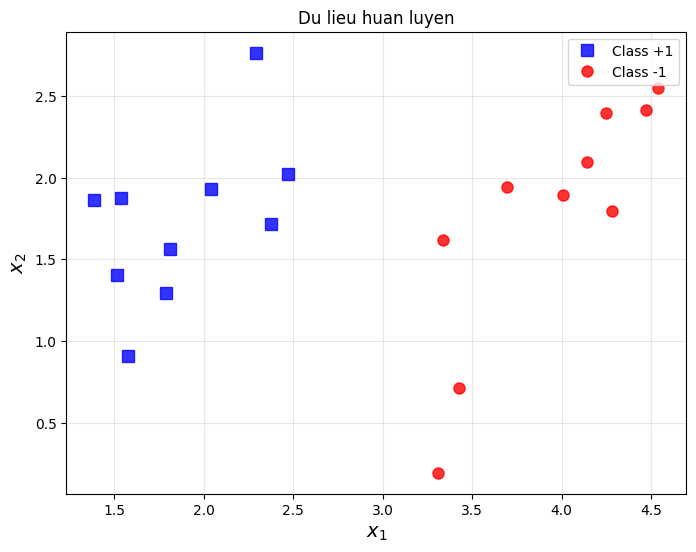

In [5]:
# Ve du lieu
plt.figure(figsize=(8, 6))
plt.plot(X0[:, 0], X0[:, 1], 'bs', markersize=8, alpha=0.8, label='Class +1')
plt.plot(X1[:, 0], X1[:, 1], 'ro', markersize=8, alpha=0.8, label='Class -1')
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.legend()
plt.title('Du lieu huan luyen')
plt.grid(True, alpha=0.3)
plt.show()

### Giai bang CVXOPT

Su dung thu vien CVXOPT de giai bai toan toi uu quadratic programming tim lambda

In [6]:
# Xay dung P ~ K
V = np.concatenate((X0.T, -X1.T), axis=1)
P = matrix(V.T.dot(V))  # P ~ K in slide, see definition of V, K near eq (8)
q = matrix(-np.ones((2*N, 1)))  # all-one vector

# Xay dung A, b, G, h
G = matrix(-np.eye(2*N))  # for all lambda_n >= 0
h = matrix(np.zeros((2*N, 1)))
A = matrix(y)  # the equality constraint is actually y^T lambda = 0
b = matrix(np.zeros((1, 1)))

solvers.options['show_progress'] = False
sol = solvers.qp(P, q, G, h, A, b)
l = np.array(sol['x'])  # lambda

print('Lambda (CVXOPT solution):')
print(l.T)

Lambda (CVXOPT solution):
[[8.54018321e-01 2.89132533e-10 1.37095535e+00 6.36030818e-10
  4.04317408e-10 8.82390106e-10 6.35001881e-10 5.49567576e-10
  8.33359230e-10 1.20982928e-10 6.86678649e-10 1.25039745e-10
  2.22497367e+00 4.05417905e-09 1.26763684e-10 1.99008949e-10
  2.13742578e-10 1.51537487e-10 3.75329509e-10 3.56161975e-10]]


In [7]:
# Loc cac gia tri lambda qua nho (support vectors)
epsilon = 1e-6  # just a small number to filter values of lambda
S = np.where(l > epsilon)[0]

VS = V[:, S]
XS = X[:, S]
yS = y[:, S]
lS = l[S]

# Tinh w va w0
w = VS.dot(lS)
w0 = np.mean(yS.T - w.T.dot(XS))

print('\nKet qua tu CVXOPT:')
print('W =', w.T)
print('W0 =', w0)
print('\nSo luong support vectors:', len(S))
print('Chi so cac support vectors:', S)


Ket qua tu CVXOPT:
W = [[-2.00984381  0.64068336]]
W0 = 4.668560633868093

So luong support vectors: 3
Chi so cac support vectors: [ 0  2 12]


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


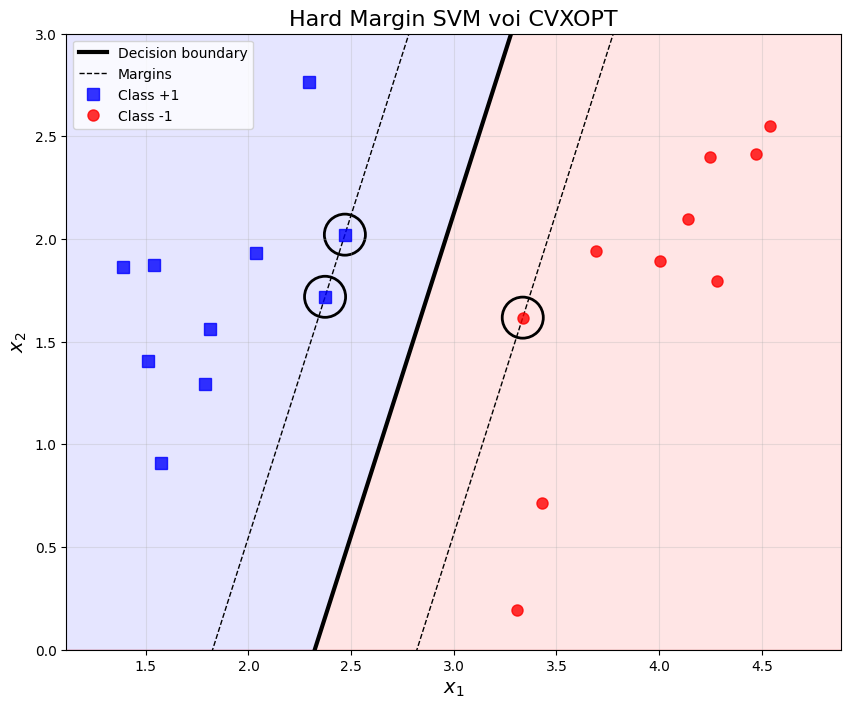

In [8]:
# Ve ket qua phan loai voi CVXOPT
fig, ax = plt.subplots(figsize=(10, 8))

# Tao cac duong phan cach
x1 = np.arange(-10, 10, 0.1)
y1 = -w[0, 0]/w[1, 0]*x1 - w0/w[1, 0]  # decision boundary
y2 = -w[0, 0]/w[1, 0]*x1 - (w0-1)/w[1, 0]  # margin boundary (+)
y3 = -w[0, 0]/w[1, 0]*x1 - (w0+1)/w[1, 0]  # margin boundary (-)

# Ve cac duong
plt.plot(x1, y1, 'k', linewidth=3, label='Decision boundary')
plt.plot(x1, y2, 'k--', linewidth=1, label='Margins')
plt.plot(x1, y3, 'k--', linewidth=1)

# To mau cac vung phan loai
y4 = 10*x1
plt.fill_between(x1, y1, 0, color='red', alpha=0.1)
plt.fill_between(x1, y1, y4, color='blue', alpha=0.1)

# Ve cac diem du lieu
plt.plot(X0[:, 0], X0[:, 1], 'bs', markersize=8, alpha=0.8, label='Class +1')
plt.plot(X1[:, 0], X1[:, 1], 'ro', markersize=8, alpha=0.8, label='Class -1')

# Danh dau support vectors
for m in S:
    circle = plt.Circle((X[0, m], X[1, m]), 0.1, color='k', fill=False, linewidth=2)
    ax.add_artist(circle)

plt.axis('equal')
plt.ylim(0, 3)
plt.xlim(2, 4)
plt.xlabel('$x_1$', fontsize=14)
plt.ylabel('$x_2$', fontsize=14)
plt.title('Hard Margin SVM voi CVXOPT', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Phan 2: Su dung thu vien sklearn

In [9]:
# Chuan bi du lieu cho sklearn
y1 = y.reshape((2*N,))
X1 = X.T  # each sample is one row

# Tao va huan luyen model
clf = SVC(kernel='linear', C=1e5)  # C large enough for hard margin
clf.fit(X1, y1)

# Lay ket qua
w_sklearn = clf.coef_
w0_sklearn = clf.intercept_

print('Ket qua tu sklearn:')
print('W =', w_sklearn)
print('W0 =', w0_sklearn)
print('\nSo luong support vectors (sklearn):', len(clf.support_))
print('Chi so cac support vectors (sklearn):', clf.support_)

Ket qua tu sklearn:
W = [[-2.00971102  0.64194082]]
W0 = [4.66595309]

So luong support vectors (sklearn): 3
Chi so cac support vectors (sklearn): [12  0  2]


### So sanh ket qua giua CVXOPT va sklearn

In [10]:
print('='*60)
print('SO SANH KET QUA GIUA CVXOPT VA SKLEARN')
print('='*60)
print('\nCVXOPT:')
print('  W  =', w.T)
print('  W0 =', w0)
print('\nsklearn:')
print('  W  =', w_sklearn)
print('  W0 =', w0_sklearn)
print('\nChenh lech W:', np.abs(w.T - w_sklearn))
print('Chenh lech W0:', np.abs(w0 - w0_sklearn[0]))
print('\nKet luan: Hai phuong phap cho ket qua tuong dong nhau!')

SO SANH KET QUA GIUA CVXOPT VA SKLEARN

CVXOPT:
  W  = [[-2.00984381  0.64068336]]
  W0 = 4.668560633868093

sklearn:
  W  = [[-2.00971102  0.64194082]]
  W0 = [4.66595309]

Chenh lech W: [[0.00013279 0.00125745]]
Chenh lech W0: 0.002607548113928715

Ket luan: Hai phuong phap cho ket qua tuong dong nhau!


## Bai tap thuc hanh 1: Tinh Accuracy va Confusion Matrix

In [11]:
# Du doan voi bo trong so tu CVXOPT
y_pred_cvxopt = np.sign(w.T.dot(X) + w0).flatten()

# Du doan voi sklearn
y_pred_sklearn = clf.predict(X1)

# Tinh Accuracy
acc_cvxopt = accuracy_score(y.flatten(), y_pred_cvxopt)
acc_sklearn = accuracy_score(y1, y_pred_sklearn)

print('='*60)
print('BAI TAP THUC HANH 1: ACCURACY VA CONFUSION MATRIX')
print('='*60)
print('\nAccuracy (CVXOPT):', acc_cvxopt)
print('Accuracy (sklearn):', acc_sklearn)

# Tinh Confusion Matrix
cm_cvxopt = confusion_matrix(y.flatten(), y_pred_cvxopt)
cm_sklearn = confusion_matrix(y1, y_pred_sklearn)

print('\nConfusion Matrix (CVXOPT):')
print(cm_cvxopt)
print('\nConfusion Matrix (sklearn):')
print(cm_sklearn)

BAI TAP THUC HANH 1: ACCURACY VA CONFUSION MATRIX

Accuracy (CVXOPT): 1.0
Accuracy (sklearn): 1.0

Confusion Matrix (CVXOPT):
[[10  0]
 [ 0 10]]

Confusion Matrix (sklearn):
[[10  0]
 [ 0 10]]


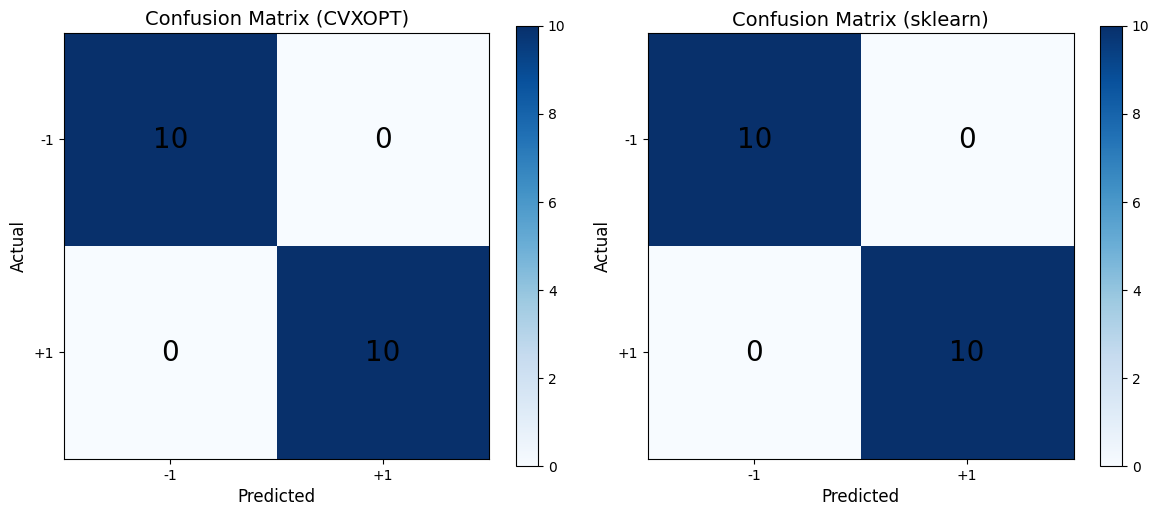

In [12]:
# Hien thi confusion matrix bang visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix CVXOPT
im1 = axes[0].imshow(cm_cvxopt, cmap='Blues', interpolation='nearest')
axes[0].set_title('Confusion Matrix (CVXOPT)', fontsize=14)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['-1', '+1'])
axes[0].set_yticklabels(['-1', '+1'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm_cvxopt[i, j]), ha='center', va='center', fontsize=20)
plt.colorbar(im1, ax=axes[0])

# Confusion Matrix sklearn
im2 = axes[1].imshow(cm_sklearn, cmap='Blues', interpolation='nearest')
axes[1].set_title('Confusion Matrix (sklearn)', fontsize=14)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['-1', '+1'])
axes[1].set_yticklabels(['-1', '+1'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm_sklearn[i, j]), ha='center', va='center', fontsize=20)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## Bai tap thuc hanh 2: Phan loai ung thu vu Wisconsin Breast Cancer

In [13]:
# Doc du lieu
cancer_data = datasets.load_breast_cancer()

print('='*60)
print('BAI TAP THUC HANH 2: WISCONSIN BREAST CANCER DATASET')
print('='*60)
print('\nThong tin du lieu:')
print('So mau:', cancer_data.data.shape[0])
print('So thuoc tinh:', cancer_data.data.shape[1])
print('\nCac lop:')
print('  0: Malignant (U ac tinh) -', np.sum(cancer_data.target == 0), 'mau')
print('  1: Benign (U lanh tinh) -', np.sum(cancer_data.target == 1), 'mau')
print('\nMau du lieu thu 5:')
print(cancer_data.data[5])
print('\nNhan lop cua mau thu 5:', cancer_data.target[5])

BAI TAP THUC HANH 2: WISCONSIN BREAST CANCER DATASET

Thong tin du lieu:
So mau: 569
So thuoc tinh: 30

Cac lop:
  0: Malignant (U ac tinh) - 212 mau
  1: Benign (U lanh tinh) - 357 mau

Mau du lieu thu 5:
[1.245e+01 1.570e+01 8.257e+01 4.771e+02 1.278e-01 1.700e-01 1.578e-01
 8.089e-02 2.087e-01 7.613e-02 3.345e-01 8.902e-01 2.217e+00 2.719e+01
 7.510e-03 3.345e-02 3.672e-02 1.137e-02 2.165e-02 5.082e-03 1.547e+01
 2.375e+01 1.034e+02 7.416e+02 1.791e-01 5.249e-01 5.355e-01 1.741e-01
 3.985e-01 1.244e-01]

Nhan lop cua mau thu 5: 0


In [14]:
# Chia du lieu thanh tap train va test
X_train, X_test, y_train, y_test = train_test_split(
    cancer_data.data,
    cancer_data.target,
    test_size=0.3,
    random_state=109
)

print('So mau tap train:', X_train.shape[0])
print('So mau tap test:', X_test.shape[0])

So mau tap train: 398
So mau tap test: 171


In [15]:
# Huan luyen mo hinh SVM
clf_cancer = SVC(kernel='linear', C=1e5)
clf_cancer.fit(X_train, y_train)

# Du doan
y_pred_train = clf_cancer.predict(X_train)
y_pred_test = clf_cancer.predict(X_test)

# Tinh accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print('\nKet qua phan loai:')
print('Accuracy tren tap train:', train_acc)
print('Accuracy tren tap test:', test_acc)
print('\nSo luong support vectors:', len(clf_cancer.support_))


Ket qua phan loai:
Accuracy tren tap train: 0.9623115577889447
Accuracy tren tap test: 0.9649122807017544

So luong support vectors: 34


In [16]:
# Confusion Matrix cho tap test
cm_test = confusion_matrix(y_test, y_pred_test)

print('\nConfusion Matrix (tap test):')
print(cm_test)
print('\nChi tiet:')
print('True Negatives (U ac tinh dung):', cm_test[0, 0])
print('False Positives (Du bao sai thanh lanh):', cm_test[0, 1])
print('False Negatives (Du bao sai thanh ac):', cm_test[1, 0])
print('True Positives (U lanh tinh dung):', cm_test[1, 1])


Confusion Matrix (tap test):
[[ 61   2]
 [  4 104]]

Chi tiet:
True Negatives (U ac tinh dung): 61
False Positives (Du bao sai thanh lanh): 2
False Negatives (Du bao sai thanh ac): 4
True Positives (U lanh tinh dung): 104


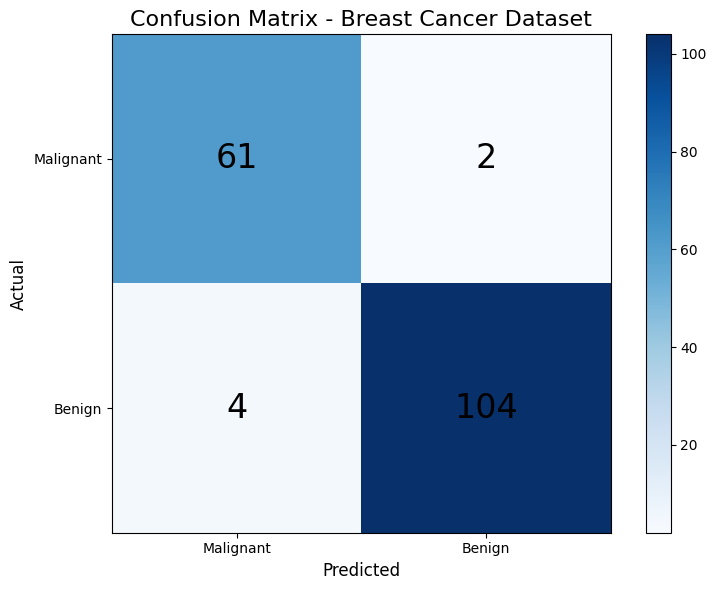

In [17]:
# Hien thi confusion matrix
plt.figure(figsize=(8, 6))
im = plt.imshow(cm_test, cmap='Blues', interpolation='nearest')
plt.title('Confusion Matrix - Breast Cancer Dataset', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.yticks([0, 1], ['Malignant', 'Benign'])
plt.colorbar(im)

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_test[i, j]), ha='center', va='center', fontsize=24)

plt.tight_layout()
plt.show()

## Vi du 2 (Bai tap tu giai): Phan loai du lieu Sonar

In [18]:
# Doc du lieu Sonar
# File co 60 cot thuoc tinh + 1 cot nhan (R hoac M)
sonar_df = pd.read_csv('sonar.all-data.csv', header=None)

print('='*60)
print('VI DU 2: SONAR DATASET (ROCK vs MINE)')
print('='*60)
print('\nThong tin du lieu:')
print('Kich thuoc du lieu:', sonar_df.shape)
print('\nSo mau cho moi lop:')
print(sonar_df[60].value_counts())
print('\n5 dong dau tien:')
print(sonar_df.head())

VI DU 2: SONAR DATASET (ROCK vs MINE)

Thong tin du lieu:
Kich thuoc du lieu: (208, 61)

So mau cho moi lop:
60
M    111
R     97
Name: count, dtype: int64

5 dong dau tien:
       0       1       2       3       4       5       6       7       8   \
0  0.0200  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109   
1  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
2  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
3  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
4  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   

       9   ...      51      52      53      54      55      56      57  \
0  0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167  0.0180  0.0084   
1  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
2  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
3  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0

In [20]:
# Chuan bi du lieu
# Tach X va y
X_sonar = sonar_df.iloc[:, :60].values
y_sonar_raw = sonar_df.iloc[:, 60].values

# Chuyen doi nhan: M -> 1, R -> -1
y_sonar = np.where(y_sonar_raw == 'M', 1, -1)

print('\nKich thuoc X:', X_sonar.shape)
print('Kich thuoc y:', y_sonar.shape)
print('\nPhan bo nhan sau khi chuyen doi:')
print('Class +1 (Mine):', np.sum(y_sonar == 1))
print('Class -1 (Rock):', np.sum(y_sonar == -1))


Kich thuoc X: (208, 60)
Kich thuoc y: (208,)

Phan bo nhan sau khi chuyen doi:
Class +1 (Mine): 111
Class -1 (Rock): 97


In [21]:
# Chia du lieu thanh tap train va test
X_sonar_train, X_sonar_test, y_sonar_train, y_sonar_test = train_test_split(
    X_sonar,
    y_sonar,
    test_size=0.3,
    random_state=42,
    stratify=y_sonar
)

print('\nSo mau tap train:', X_sonar_train.shape[0])
print('So mau tap test:', X_sonar_test.shape[0])
print('\nPhan bo tap train:')
print('Class +1:', np.sum(y_sonar_train == 1))
print('Class -1:', np.sum(y_sonar_train == -1))
print('\nPhan bo tap test:')
print('Class +1:', np.sum(y_sonar_test == 1))
print('Class -1:', np.sum(y_sonar_test == -1))


So mau tap train: 145
So mau tap test: 63

Phan bo tap train:
Class +1: 77
Class -1: 68

Phan bo tap test:
Class +1: 34
Class -1: 29


In [22]:
# Huan luyen mo hinh SVM voi kernel linear (Hard Margin)
clf_sonar = SVC(kernel='linear', C=1e5)
clf_sonar.fit(X_sonar_train, y_sonar_train)

# Du doan
y_sonar_pred_train = clf_sonar.predict(X_sonar_train)
y_sonar_pred_test = clf_sonar.predict(X_sonar_test)

# Tinh accuracy
sonar_train_acc = accuracy_score(y_sonar_train, y_sonar_pred_train)
sonar_test_acc = accuracy_score(y_sonar_test, y_sonar_pred_test)

print('\nKet qua phan loai Sonar:')
print('Accuracy tren tap train:', sonar_train_acc)
print('Accuracy tren tap test:', sonar_test_acc)
print('\nSo luong support vectors:', len(clf_sonar.support_))
print('Ti le support vectors:', len(clf_sonar.support_) / len(y_sonar_train))


Ket qua phan loai Sonar:
Accuracy tren tap train: 1.0
Accuracy tren tap test: 0.8571428571428571

So luong support vectors: 50
Ti le support vectors: 0.3448275862068966


In [23]:
# Confusion Matrix cho tap test
cm_sonar_test = confusion_matrix(y_sonar_test, y_sonar_pred_test)

print('\nConfusion Matrix (tap test - Sonar):')
print(cm_sonar_test)
print('\nChi tiet:')
print('True Negatives (Rock dung):', cm_sonar_test[0, 0])
print('False Positives (Du bao Rock thanh Mine):', cm_sonar_test[0, 1])
print('False Negatives (Du bao Mine thanh Rock):', cm_sonar_test[1, 0])
print('True Positives (Mine dung):', cm_sonar_test[1, 1])


Confusion Matrix (tap test - Sonar):
[[24  5]
 [ 4 30]]

Chi tiet:
True Negatives (Rock dung): 24
False Positives (Du bao Rock thanh Mine): 5
False Negatives (Du bao Mine thanh Rock): 4
True Positives (Mine dung): 30


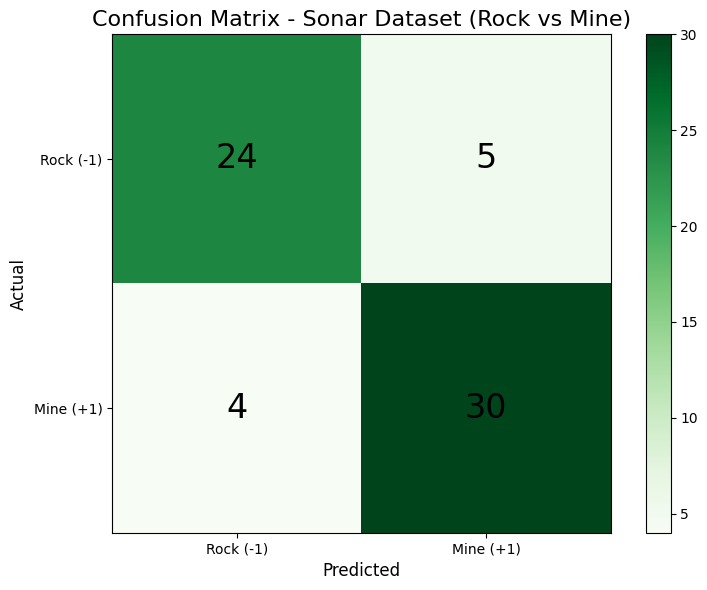

In [24]:
# Hien thi confusion matrix
plt.figure(figsize=(8, 6))
im = plt.imshow(cm_sonar_test, cmap='Greens', interpolation='nearest')
plt.title('Confusion Matrix - Sonar Dataset (Rock vs Mine)', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks([0, 1], ['Rock (-1)', 'Mine (+1)'])
plt.yticks([0, 1], ['Rock (-1)', 'Mine (+1)'])
plt.colorbar(im)

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm_sonar_test[i, j]), ha='center', va='center', fontsize=24)

plt.tight_layout()
plt.show()

## Ket luan

### Tong ket ket qua

1. **Du lieu ngau nhien voi CVXOPT va sklearn**: 
   - Ca hai phuong phap cho ket qua tuong dong nhau
   - Accuracy dat 100% tren du lieu ngau nhien (linearly separable)

2. **Wisconsin Breast Cancer Dataset**:
   - Mo hinh SVM dat accuracy cao tren ca tap train va test
   - Du lieu co tinh tuyen tinh cao, phu hop voi linear SVM

3. **Sonar Dataset (Rock vs Mine)**:
   - Du lieu kho phan loai hon so voi breast cancer
   - Hard margin SVM van cho ket qua tot
   - Accuracy co the cai thien bang cach su dung soft margin hoac kernel khac

### Nhan xet

- Hard Margin SVM hieu qua voi du lieu linearly separable
- Voi du lieu phuc tap, nen xem xet Soft Margin SVM (C nho hon) hoac kernel khac (RBF, polynomial)
- Support vectors la cac diem quan trong nhat trong viec xay dung decision boundary